# Homework 5: Precipitation Nowcasting using Neural Networks

In this exercise, you are going to build a set of deep learning models on a real world task using PyTorch. PyTorch is an open source machine learning framework based on the Torch library, used for applications such as computer vision and natural language processing, primarily developed by Facebook's AI Research lab (FAIR).

## Setting up to use the gpu  

Before we start, we need to change the environment of Colab to use GPU. Do so by:

Runtime -> Change runtime type -> Hardware accelerator -> GPU

## Deep Neural Networks with PyTorch ##

To complete this exercise, you will need to build deep learning models for precipitation nowcasting. You will build a subset of the models shown below:
- Fully Connected (Feedforward) Neural Network
- Two-Dimentional Convolution Neural Network (2D-CNN)
- Recurrent Neural Network with Gated Recurrent Unit (GRU)

and one more model of your choice to achieve the highest score possible.

We provide the code for data cleaning and some starter code for PyTorch in this notebook but feel free to modify those parts to suit your needs. Feel free to use additional libraries (e.g. scikit-learn) as long as you have a model for each type mentioned above.

This notebook assumes you have already installed PyTorch with python3 and had GPU enabled. If you run this exercise on Colab you are all set.

## Precipitation Nowcasting ##

Precipitation nowcasting is the the task of predicting the amount of rainfall in a certain region given some kind of sensor data.  The term nowcasting refers to tasks that try to predict the current or near future conditions (within 6 hours).

You will be given satellite images in 3 different bands covering a 5 by 5 region from different parts of Thailand. In other words, your input will be a 5x5x3 image. Your task is to predict the amount of rainfall in the center pixel. You will first do the prediction using just a simple fully-connected neural network that view each pixel as different input features.

Since the your input is basically an image, we will then view the input as an image and apply CNN to do the prediction. Finally, we can also add a time component since weather prediction can benefit greatly using previous time frames. Each data point actually contain 5 time steps, so each input data point has a size of 5x5x5x3 (time x height x width x channel), and the output data has a size of 5 (time). You will use this time information when you work with RNNs.

Finally, we would like to thank the Thai Meteorological Department for providing the data for this assignment.

In [1]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [2]:
# For summarizing and visualizing models
!pip install torchinfo
!pip install torchviz

## Weights and Biases

[Weights and Biases](https://docs.wandb.ai/company) (wandb) is an experiment tracking tool for machine learning. It can log and visualize experiments in real time. It supports many popular ML frameworks, and obviously PyTorch is one of them. In this notebook you will learn how to log general metrics like losses, parameter distributions, and gradient distribution with wandb.

To install wandb, run the cell below

In [3]:
!pip install wandb

## Setup

1. Register [Wandb account](https://wandb.ai/login?signup=true) (and confirm your email)

2. `wandb login` and copy paste the API key when prompt

In [ ]:
!wandb login

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 

In [1]:
import wandb
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/tan/.netrc
wandb: Currently logged in as: tanparkorn (tanparkorn-chulalongkorn-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
import os
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import urllib
import wandb
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms

from sklearn import preprocessing
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchinfo import summary
from tqdm.notebook import tqdm

torch.__version__

'2.9.1'

## Loading the data

The data is on huggingface, a website that allows people to share datasets and pretrained models.

In [5]:
from huggingface_hub import hf_hub_download
hf_hub_download(repo_id="ecitslos/HWnowcastingdata", filename="nowcastingHWdataset.tar.gz", repo_type="dataset", local_dir=".")

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'nowcastingHWdataset.tar.gz'

In [6]:
!tar -xvf './nowcastingHWdataset.tar.gz'

x dataset/features-m10.pk
x dataset/features-m6.pk
x dataset/features-m7.pk
x dataset/features-m8.pk
x dataset/features-m9.pk
x dataset/labels-m10.pk
x dataset/labels-m6.pk
x dataset/labels-m7.pk
x dataset/labels-m8.pk
x dataset/labels-m9.pk


# Data Explanation #

The data is an hourly measurement of water vapor in the atmosphere, and two infrared measurements of cloud imagery on a latitude-longitude coordinate. Each measurement is illustrated below as an image. These three features are included as different channels in your input data.

<img src="https://raw.githubusercontent.com/burin-n/pattern-recognition/master/HW4/images/wvapor.png" width="200"> <img src="https://raw.githubusercontent.com/burin-n/pattern-recognition/master/HW4/images/cloud1.png" width="200"> <img src="https://raw.githubusercontent.com/burin-n/pattern-recognition/master/HW4/images/cloud2.png" width="200">

We also provide the hourly precipitation (rainfall) records in the month of June, July, August, September, and October from weather stations spreaded around the country. A 5x5 grid around each weather station at a particular time will be paired with the precipitation recorded at the corresponding station as input and output data. Finally, five adjacent timesteps are stacked into one sequence.

The month of June-August are provided as training data, while the months of September and October are used as validation and test sets, respectively.


# Reading data

In [7]:
def read_data(months, data_dir='dataset'):
    features = np.array([], dtype=np.float32).reshape(0,5,5,5,3)
    labels = np.array([], dtype=np.float32).reshape(0,5)
    for m in months:
        filename = 'features-m{}.pk'.format(m)
        with open(os.path.join(data_dir,filename), 'rb') as file:
            features_temp = pickle.load(file)
        features = np.concatenate((features, features_temp), axis=0)

        filename = 'labels-m{}.pk'.format(m)
        with open(os.path.join(data_dir,filename), 'rb') as file:
            labels_temp = pickle.load(file)
        labels = np.concatenate((labels, labels_temp), axis=0)

    return features, labels

In [8]:
# use data from month 6,7,8 as training set
x_train, y_train = read_data(months=[6,7,8])

# use data from month 9 as validation set
x_val, y_val = read_data(months=[9])

# use data from month 10 as test set
x_test, y_test = read_data(months=[10])

print('x_train shape:',x_train.shape)
print('y_train shape:', y_train.shape, '\n')
print('x_val shape:',x_val.shape)
print('y_val shape:', y_val.shape, '\n')
print('x_test shape:',x_test.shape)
print('y_test shape:', y_test.shape)

/var/folders/0p/v7vlt28j0f59fgqf920_rlxh0000gn/T/ipykernel_2472/1757501052.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  features_temp = pickle.load(file)
/var/folders/0p/v7vlt28j0f59fgqf920_rlxh0000gn/T/ipykernel_2472/1757501052.py:12: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  labels_temp = pickle.load(file)


x_train shape: (229548, 5, 5, 5, 3)
y_train shape: (229548, 5) 

x_val shape: (92839, 5, 5, 5, 3)
y_val shape: (92839, 5) 

x_test shape: (111715, 5, 5, 5, 3)
y_test shape: (111715, 5)


**features**
- dim 0: number of entries
- dim 1: number of time-steps in ascending order
- dim 2,3: a 5x5 grid around rain-measued station
- dim 4: water vapor and two cloud imagenaries

**labels**
- dim 0: number of entries
- dim 1: number of precipitation for each time-step

# Three-Layer Feedforward Neural Networks

In [9]:
# Dataset need to be reshaped to make it suitable for feedforword model
def preprocess_for_ff(x_train, y_train, x_val, y_val):
    x_train_ff = x_train.reshape((-1, 5*5*3))
    y_train_ff = y_train.reshape((-1, 1))
    x_val_ff = x_val.reshape((-1, 5*5*3))
    y_val_ff = y_val.reshape((-1, 1))
    x_test_ff = x_test.reshape((-1, 5*5*3))
    y_test_ff = y_test.reshape((-1, 1))

    return x_train_ff, y_train_ff, x_val_ff, y_val_ff, x_test_ff, y_test_ff

x_train_ff, y_train_ff, x_val_ff, y_val_ff, x_test_ff, y_test_ff = preprocess_for_ff(x_train, y_train, x_val, y_val)
print(x_train_ff.shape, y_train_ff.shape)
print(x_val_ff.shape, y_val_ff.shape)
print(x_test_ff.shape, y_test_ff.shape)

(1147740, 75) (1147740, 1)
(464195, 75) (464195, 1)
(558575, 75) (558575, 1)


### T1

Explain each line of code in the function preprocess_for_ff()

**Ans:** The function flattens the spatial dimensions and remove the time dimension into the batch dimension so the feedforward network can process each frame independently.

## Dataset

To prepare a DataLoader in order to feed data into the model, we need to create a `torch.utils.data.Dataset` object first. (Learn more about it [here](https://pytorch.org/docs/stable/data.html#map-style-datasets))

Dataset is a simple class that the DataLoader will get data from, most of its functionality comes from `__getitem__(self, index)` method, which will return a single data point (both input and label). In real world scenarios the method can do some other stuffs such as

1. Load images

If your input (x) are images. Oftentimes you won't be able to fit all the training images into your RAM. Thus, you should pass an array (or list) of image path into the dataloader, and the `__getitem__` will be the one who dynamically loads the actual image from the harddisk for you.

2. Data Normalization

Data normalization helps improve stability of training. Unnormalized data can cause gradients to explode. There are many variants of normalization, but in this notebook we will use either minmax or z-score (std) normalization. Read [this](https://developers.google.com/machine-learning/data-prep/transform/normalization) (or google) if you wish to learn more about data normalization.

3. Data Augmentation

In computer vision, you might want to apply small changes to the images you use in training (adjust brightness, contrast, rotation) so that the model will generalize better on unseen data. There are two kinds of augmentation: static and dynamic. Static augmentation will augment images and save to disk as a new dataset. On the other hand, rather than applying the change initially and use the same change on each image every epoch, dynamic augmentation will augment each data differently for each epoch. Note that augmentation is usually done on the CPU and you might be bounded by the CPU instead. PyTorch has a dedicated [documentation about data augmentation](https://pytorch.org/vision/master/transforms.html) if you want to know more.

In [10]:
class RainfallDatasetFF(Dataset):
    def __init__(self, x, y, normalizer):
        self.x = x.astype(np.float32)
        self.y = y.astype(np.float32)
        self.normalizer = normalizer
        print(self.x.shape)
        print(self.y.shape)

    def __getitem__(self, index):
        x = self.x[index] # Retrieve data
        x = self.normalizer.transform(x.reshape(1, -1)) # Normalize
        y = self.y[index]
        return x, y

    def __len__(self):
        return self.x.shape[0]

In [11]:
def normalizer_std(X):
    scaler = preprocessing.StandardScaler().fit(X)
    return scaler

def normalizer_minmax(X):
    scaler = preprocessing.MinMaxScaler().fit(X)
    return scaler

In [12]:
normalizer = normalizer_std(x_train_ff) # We will normalize everything based on x_train

train_dataset = RainfallDatasetFF(x_train_ff, y_train_ff, normalizer)
val_dataset = RainfallDatasetFF(x_val_ff, y_val_ff, normalizer)
test_dataset = RainfallDatasetFF(x_test_ff, y_test_ff, normalizer)

(1147740, 75)
(1147740, 1)
(464195, 75)
(464195, 1)
(558575, 75)
(558575, 1)


## DataLoader

DataLoader feeds data from our dataset into the model. We can freely customize batch size, data shuffle for each data split, and much more with DataLoader class. If you're curious about what can you do with PyTorch's DataLoader, you can check [this documentation](https://pytorch.org/docs/stable/data.html)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1024, shuffle=False, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False, pin_memory=True)

## Loss Function

PyTorch has many loss functions readily available for use. We can also write our own custom loss function as well. But for now, we will use [PyTorch's built-in mean squared error loss ](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)

In [14]:
loss_fn = nn.MSELoss()

### T2

Why is the loss MSE?

**Ans:** MSE is used because the model predicts a continuous value (precipitation), making this a regression task. MSE measures how far the predictions are from the true values.

## Device

Unlike Tensorflow/Keras, PyTorch allows user to freely put any Tensor or objects (loss functions, models, optimizers, etc.) in CPU or GPU. By default, all objects created will be in CPU. In order to use GPU we will have to supply `device = torch.device("cuda")` into the objects to move it to GPU. You will usually see the syntax like `object.to(device)` for moving CPU object to GPU, or `o = Object(..., device=device)` to create the object in the GPU.

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Model

Below, the code for creating a 3-layers fully connected neural network in PyTorch is provided. Run the code and make sure you understand what you are doing. Then, report the results.

In [16]:
class FeedForwardNN(nn.Module):
    def __init__(self, hidden_size=200):
        super(FeedForwardNN, self).__init__()
        self.ff1 = nn.Linear(75, hidden_size)
        self.ff2 = nn.Linear(hidden_size, hidden_size)
        self.ff3 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        hd1 = F.relu(self.ff1(x))
        hd2 = F.relu(self.ff2(hd1))
        y = F.relu(self.ff3(hd2))
        y = self.out(y)
        return y.reshape(-1, 1)

### T3

What is the activation function in the final dense layer? and why? Do you think there is a better activation function for the final layer?

**Ans:** The final dense layer does not use an activation function. For regression tasks, using no activation (a linear output layer) is typically the best choice because it allows unrestricted continuous outputs. Therefore, the current design is already appropriate.

In [17]:
# Hyperparameters and other configs
config = {
    'architecture': 'feedforward',
    'lr': 0.01,
    'hidden_size': 200,
    'scheduler_factor': 0.2,
    'scheduler_patience': 2,
    'scheduler_min_lr': 1e-4,
    'epochs': 10
}

# Model
model_ff = FeedForwardNN(hidden_size=config['hidden_size'])
model_ff = model_ff.to(device)
optimizer = torch.optim.Adam(model_ff.parameters(), lr=config['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    'min',
    factor=config['scheduler_factor'],
    patience=config['scheduler_patience'],
    min_lr=config['scheduler_min_lr']
)

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


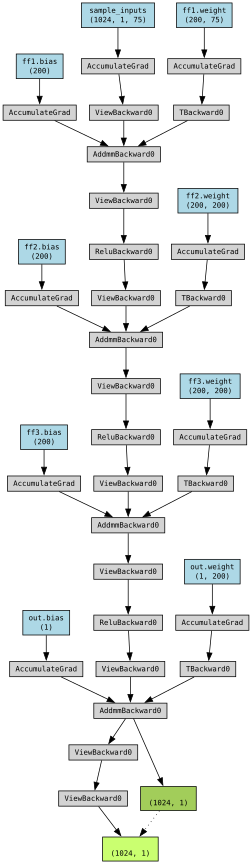

In [18]:
from torchviz import make_dot
# Visualize model with torchviz
sample_inputs = next(iter(train_loader))[0].requires_grad_(True)
sample_y = model_ff(sample_inputs.to(device))
make_dot(sample_y, params=dict(list(model_ff.named_parameters())+[('sample_inputs', sample_inputs)]))

In [19]:
summary(model_ff, input_size=(1024, 75))

Layer (type:depth-idx)                   Output Shape              Param #
FeedForwardNN                            [1024, 1]                 --
├─Linear: 1-1                            [1024, 200]               15,200
├─Linear: 1-2                            [1024, 200]               40,200
├─Linear: 1-3                            [1024, 200]               40,200
├─Linear: 1-4                            [1024, 1]                 201
Total params: 95,801
Trainable params: 95,801
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 98.10
Input size (MB): 0.31
Forward/backward pass size (MB): 4.92
Params size (MB): 0.38
Estimated Total Size (MB): 5.61

### T4

Explain why the first linear layer has number of parameters = 15200

**Ans:** Linear(75 → 200): 75 × 200 + 200 = 15200

# Training

In [21]:
from tqdm.auto import tqdm

train_losses = []
val_losses = []
learning_rates = []

# Start wandb run
wandb.init(
    project='precipitation-nowcasting-2026',
    config=config,
)

# Log parameters and gradients
# This makes the training slow. Do this when you are debugging only.
# You should avoid doing this when doing serious training.
wandb.watch(model_ff, log='all')

for epoch in range(config['epochs']):  # loop over the dataset multiple times

    # Training
    train_loss = []
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    # Flag model as training. Some layers behave differently in training and
    # inference modes, such as dropout, BN, etc.
    model_ff.train()

    print(f"Training epoch {epoch+1}...")
    print(f"Current LR: {current_lr}")

    for i, (inputs, y_true) in enumerate(tqdm(train_loader)):
        # Transfer data from cpu to gpu
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        # Reset the gradient
        optimizer.zero_grad()

        # Predict
        y_pred = model_ff(inputs)

        # Calculate loss
        loss = loss_fn(y_pred, y_true)

        # Compute gradient
        loss.backward()

        # Update parameters
        optimizer.step()

        # Log stuff
        train_loss.append(loss)

    avg_train_loss = torch.stack(train_loss).mean().item()
    train_losses.append(avg_train_loss)

    print(f"Epoch {epoch+1} train loss: {avg_train_loss:.4f}")

    # Validation
    model_ff.eval()
    with torch.no_grad(): # No gradient is required during validation
        print(f"Validating epoch {epoch+1}")
        val_loss = []
        for i, (inputs, y_true) in enumerate(tqdm(val_loader)):
            # Transfer data from cpu to gpu
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            # Predict
            y_pred = model_ff(inputs)

            # Calculate loss
            loss = loss_fn(y_pred, y_true)

            # Log stuff
            val_loss.append(loss)

        avg_val_loss = torch.stack(val_loss).mean().item()
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch+1} val loss: {avg_val_loss:.4f}")

        # LR adjustment with scheduler
        scheduler.step(avg_val_loss)

        # Save checkpoint if val_loss is the best we got
        best_val_loss = np.inf if epoch == 0 else min(val_losses[:-1])
        if avg_val_loss < best_val_loss:
            # Save whatever you want
            state = {
                'epoch': epoch,
                'model': model_ff.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'best_val_loss': best_val_loss,
            }

            print(f"Saving new best model..")
            torch.save(state, 'model_ff.pth.tar')

    wandb.log({
        'train_loss': avg_train_loss,
        'val_loss': avg_val_loss,
        'lr': current_lr,
    })

wandb.finish()
print('Finished Training')

Training epoch 1...
Current LR: 0.01



  0%|                                                  | 0/1121 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

100%|███████████████████████████████████████| 1121/1121 [00:33<00:00, 33.09it/s]


Epoch 1 train loss: 1.9267
Validating epoch 1



  0%|                                                   | 0/454 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

100%|█████████████████████████████████████████| 454/454 [00:12<00:00, 37.24it/s]


Epoch 1 val loss: 1.6609
Saving new best model..
Training epoch 2...
Current LR: 0.01


...

Epoch 10 train loss: 1.9232
Validating epoch 10



  0%|                                                   | 0/454 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

100%|█████████████████████████████████████████| 454/454 [00:12<00:00, 34.93it/s]

Epoch 10 val loss: 1.6612


lr,█████▂▂▂▁▁
train_loss,█▁▃▃▄▄▃▃▅▃
val_loss,▄▁█▃▄▄▅▅▄▅
lr,0.0004
train_loss,1.92322
val_loss,1.66116


Finished Training


You might want to download the saved model (model_ff.pth.tar) for later uses if you are running on Colab.

### T5

Plot loss and val_loss as a function of epochs.

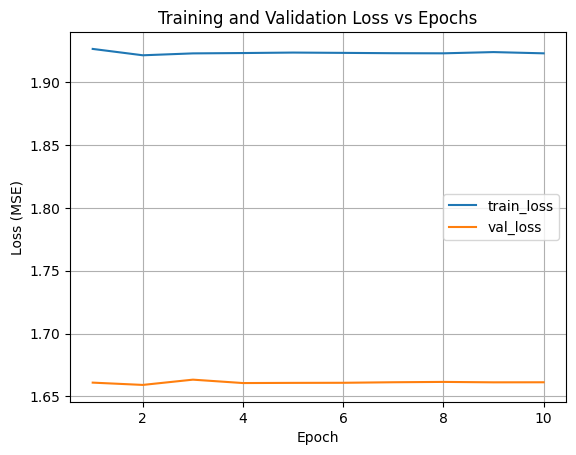

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="train_loss")
plt.plot(epochs, val_losses, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

### T6

When does the model start to overfit?

**Ans:** The model does not show clear signs of overfitting within the 10 training epochs because validation loss does not increase while training loss decreases. Both losses remain relatively stable.

### T7

Plot the learning rate as a function of the epochs.

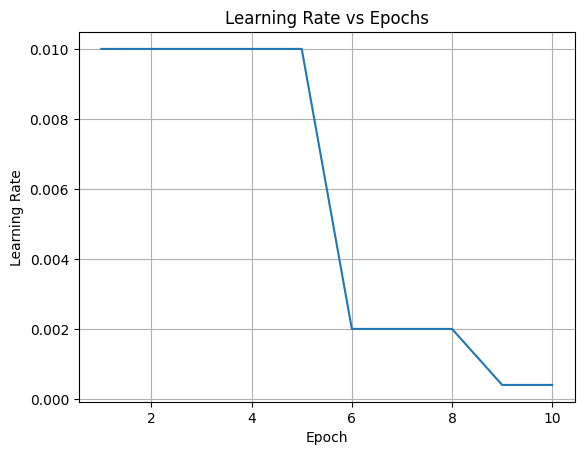

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, len(learning_rates) + 1)

plt.figure()
plt.plot(epochs, learning_rates)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate vs Epochs")
plt.grid(True)
plt.show()

### T8

What makes the learning rate change?
(hint: try to understand the scheduler [ReduceLROnPlateau](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html))


**Ans:** The learning rate changes because the scheduler ReduceLROnPlateau monitors the validation loss. When the validation loss stops improving for a certain number of epochs (defined by the scheduler’s patience parameter), the scheduler reduces the learning rate by multiplying it by a factor. In the plot, the learning rate decreases after the validation loss plateaus, allowing the optimizer to take smaller steps and potentially improve convergence.

# Load Model

Use the code snippet below to load the model you just trained

In [24]:
checkpoint = torch.load('model_ff.pth.tar')
loaded_model = FeedForwardNN(hidden_size=config['hidden_size']) # Create model object
loaded_model.load_state_dict(checkpoint['model']) # Load weights
print(f"Loaded epoch {checkpoint['epoch']} model")

Loaded epoch 1 model


# A more complex scheduling

The scheduler can be very complicated and you can write your own heuristic for it.

### T9

Implement a custom learning rate scheduler that behaves like the following graph.

You might want to learn how to use [PyTorch's built-in learning rate schedulers](https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) in order to build your own.

Learning rate should be function of epoch.

![](https://raw.githubusercontent.com/pjumruspun/ComProg2021-Workshop/main/graph.png)

In [25]:
class MyScheduler():
    def __init__(self, optimizer: torch.optim.Optimizer):
        self.optimizer = optimizer

    def step(self, epoch):
        # Learning rate schedule based on the graph
        if epoch <= 3:
            lr = 1e-4 + (epoch/3)*(1e-3 - 1e-4)
        elif epoch <= 6:
            lr = 1e-3 - ((epoch-3)/3)*(1e-3 - 5e-4)
        elif epoch <= 7:
            lr = 5e-4 + (epoch-6)*(1e-3 - 5e-4)
        elif epoch <= 9:
            lr = 1e-3 - ((epoch-7)/2)*(1e-3 - 1e-4)
        else:
            lr = 1e-4

        for g in self.optimizer.param_groups:
            g['lr'] = lr

In [28]:
import numpy as np
import torch
from tqdm.auto import tqdm
import wandb

# -----------------------
# Custom scheduler (T9)
# -----------------------
class MyScheduler():
    def __init__(self, optimizer: torch.optim.Optimizer):
        self.optimizer = optimizer

    def step(self, epoch):
        # piecewise-linear schedule matching the plot
        if epoch <= 3:
            lr = 1e-4 + (epoch / 3) * (1e-3 - 1e-4)
        elif epoch <= 6:
            lr = 1e-3 - ((epoch - 3) / 3) * (1e-3 - 5e-4)
        elif epoch <= 7:
            lr = 5e-4 + (epoch - 6) * (1e-3 - 5e-4)
        elif epoch <= 9:
            lr = 1e-3 - ((epoch - 7) / 2) * (1e-3 - 1e-4)
        else:
            lr = 1e-4

        for g in self.optimizer.param_groups:
            g["lr"] = lr


# -----------------------
# W&B setup (safe)
# -----------------------
# Close any half-open run safely
try:
    wandb.finish()
except Exception:
    pass

run = wandb.init(
    project="precipitation-nowcasting-2026",
    config=config,
    reinit=True,              # safe if you rerun the cell
)

# DON'T use log='all' (it can be heavy and is where your crash came from)
# Use gradients or None.
wandb.watch(model_ff, log="gradients", log_freq=200)


# -----------------------
# Training with scheduler
# -----------------------
my_scheduler = MyScheduler(optimizer)

train_losses = []
val_losses = []
learning_rates = []

best_val_loss = float("inf")

for epoch in range(config["epochs"]):

    # set LR for this epoch (T9 requirement)
    my_scheduler.step(epoch)
    current_lr = optimizer.param_groups[0]["lr"]
    learning_rates.append(current_lr)

    # ---- train ----
    model_ff.train()
    batch_train_losses = []

    for inputs, y_true in tqdm(train_loader, desc=f"Train {epoch+1}/{config['epochs']}"):
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        optimizer.zero_grad()
        y_pred = model_ff(inputs)
        loss = loss_fn(y_pred, y_true)
        loss.backward()
        optimizer.step()

        batch_train_losses.append(loss.detach())

    avg_train_loss = torch.stack(batch_train_losses).mean().item()
    train_losses.append(avg_train_loss)

    # ---- val ----
    model_ff.eval()
    batch_val_losses = []
    with torch.no_grad():
        for inputs, y_true in tqdm(val_loader, desc=f"Val {epoch+1}/{config['epochs']}"):
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            y_pred = model_ff(inputs)
            loss = loss_fn(y_pred, y_true)
            batch_val_losses.append(loss.detach())

    avg_val_loss = torch.stack(batch_val_losses).mean().item()
    val_losses.append(avg_val_loss)

    # ---- checkpoint best ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        state = {
            "epoch": epoch,
            "model": model_ff.state_dict(),
            "optimizer": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "best_val_loss": best_val_loss,
        }
        torch.save(state, "model_ff_t9.pth.tar")

    # ---- wandb log ----
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "lr": current_lr,
        "best_val_loss": best_val_loss,
    })

    print(f"Epoch {epoch+1}: train={avg_train_loss:.4f} val={avg_val_loss:.4f} lr={current_lr:.6f}")

wandb.finish()
print("Finished T9 Training")

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



Train 1/10:   0%|                                      | 0/1121 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Train 1/10: 100%|███████████████████████████| 1121/1121 [00:33<00:00, 33.12it/s]

Val 1/10:   0%|                                         | 0/454 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Val 1/10: 100%|███████████████████████████████| 454/454 [00:12<00:00, 35.14it/s]


Epoch 1: train=1.9232 val=1.6612 lr=0.000100



Train 2/10:   0%|                                      | 0/1121 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Train 2/10: 100%|███████████████████████████| 1121/1121 [00:34<00:00, 32.60it/s]

Val 2/10:   0%|                                         | 0/454 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Val 2/10: 100%|███████████████████████████████| 454/454 [00:12<00:00, 35.71it/s]


Epoch 2: train=1.9234 val=1.6612 lr=0.000400


...

Epoch 9: train=1.9223 val=1.6575 lr=0.000550



Train 10/10:   0%|                                     | 0/1121 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Train 10/10: 100%|██████████████████████████| 1121/1121 [00:33<00:00, 33.16it/s]

Val 10/10:   0%|                                        | 0/454 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Val 10/10: 100%|██████████████████████████████| 454/454 [00:13<00:00, 34.87it/s]

Epoch 10: train=1.9195 val=1.6570 lr=0.000100


best_val_loss,████████▂▁
epoch,▁▂▃▃▄▅▆▆▇█
lr,▁▃▆█▇▅▄█▄▁
train_loss,▇▇▇▇██▇█▆▁
val_loss,▇▇█▇▇▇▇▇▂▁
best_val_loss,1.65703
epoch,10
lr,0.0001
train_loss,1.9195
val_loss,1.65703


Finished T9 Training


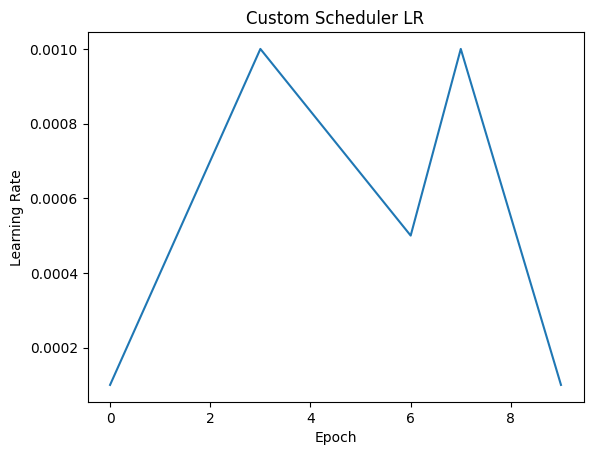

In [29]:
plt.plot(learning_rates)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Custom Scheduler LR")
plt.show()

# [Optional] Wandb #

You should now have a project in wandb with the name `precipitation-nowcasting`, which you should see the latest run you just finished inside the project. If you look into the run, you should be able to see plots of learning rate, train loss, val loss in the `Charts` section. Below it should be `Gradients` and `Parameters` section.

# Wandb Observation #

### OT1

Write your own interpretation of the logs from this example. A simple sentence or two for each section is sufficient.

**Your answer:**

# Evaluation

In [ ]:
################################################################################
# T10:                                                                     #
# Write a function to evaluate your model. Your function must predicts         #
# using the input model and return mean square error of the model.             #
#                                                                              #
# Hint: Read how to use PyTorch's MSE Loss                                     #
# https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
def evaluate(data_loader, model):
    """
    Evaluate model on validation data given by data_loader
    """
    # write code here

    return mse

In [ ]:
# We will use majority rule as a baseline.
def majority_baseline(label_set):
    unique, counts = np.unique(label_set, return_counts=True)
    majority = unique[np.argmax(counts)]
    baseline = 0
    label_set = label_set.reshape(-1,1)
    for r in label_set:
        baseline += (majority - r) ** 2 / len(label_set)
    return baseline

In [ ]:
print('baseline')
print('train', majority_baseline(y_train))
print('validate', majority_baseline(y_val))

In [ ]:
print('FF-model')
print('train', evaluate(train_loader, model_ff).item())
print('validate', evaluate(val_loader, model_ff).item())

# Dropout #

You might notice that the 3-layered feedforward does not use dropout at all. Now, try adding dropout (dropout rate of 20%) to the model, run, and report the result again.

To access PyTorch's dropout, use `nn.Dropout`. Read more about PyTorch's built-in Dropout layer [here](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)

In [30]:
################################################################################
# T11:                                                                     #
# Write a feedforward model with dropout                                       #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
import torch
import torch.nn as nn
import torch.nn.functional as F

class FeedForwardNN_Dropout(nn.Module):
    def __init__(self, hidden_size=200, dropout_p=0.2):
        super().__init__()
        self.ff1 = nn.Linear(75, hidden_size)
        self.ff2 = nn.Linear(hidden_size, hidden_size)
        self.ff3 = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, 1)
        self.drop = nn.Dropout(p=dropout_p)

    def forward(self, x):
        x = F.relu(self.ff1(x))
        x = self.drop(x)
        x = F.relu(self.ff2(x))
        x = self.drop(x)
        x = F.relu(self.ff3(x))
        x = self.drop(x)
        x = self.out(x)               # final layer: linear
        return x.reshape(-1, 1)

In [31]:
################################################################################
# T12:                                                                     #
# Complete the code to train your dropout model                                #
################################################################################
print('start training ff dropout')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
print('start training ff dropout')

import numpy as np
from tqdm.auto import tqdm
import wandb

# Build model
model_ff_do = FeedForwardNN_Dropout(
    hidden_size=config['hidden_size'],
    dropout_p=0.2
).to(device)

# Optimizer / loss / scheduler (same style as before)
optimizer_do = torch.optim.Adam(model_ff_do.parameters(), lr=config['lr'])
loss_fn = torch.nn.MSELoss()
scheduler_do = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_do, factor=config['scheduler_factor'], patience=config['scheduler_patience']
)

# Logs
train_losses_do = []
val_losses_do = []
learning_rates_do = []

# Start wandb run (safe)
try:
    wandb.finish()
except Exception:
    pass

wandb.init(project='precipitation-nowcasting-2026', config={**config, "dropout_p": 0.2}, reinit=True)
wandb.watch(model_ff_do, log="gradients", log_freq=200)

best_val_loss = float("inf")

for epoch in range(config['epochs']):

    # ---- Train ----
    model_ff_do.train()
    batch_train_losses = []

    current_lr = optimizer_do.param_groups[0]['lr']
    learning_rates_do.append(current_lr)

    for inputs, y_true in tqdm(train_loader, desc=f"Train DO {epoch+1}/{config['epochs']}"):
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        optimizer_do.zero_grad()
        y_pred = model_ff_do(inputs)
        loss = loss_fn(y_pred, y_true)
        loss.backward()
        optimizer_do.step()

        batch_train_losses.append(loss.detach())

    avg_train_loss = torch.stack(batch_train_losses).mean().item()
    train_losses_do.append(avg_train_loss)

    # ---- Val ----
    model_ff_do.eval()
    batch_val_losses = []
    with torch.no_grad():
        for inputs, y_true in tqdm(val_loader, desc=f"Val DO {epoch+1}/{config['epochs']}"):
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            y_pred = model_ff_do(inputs)
            loss = loss_fn(y_pred, y_true)
            batch_val_losses.append(loss.detach())

    avg_val_loss = torch.stack(batch_val_losses).mean().item()
    val_losses_do.append(avg_val_loss)

    # Scheduler step
    scheduler_do.step(avg_val_loss)

    # Save best
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            "epoch": epoch,
            "model": model_ff_do.state_dict(),
            "optimizer": optimizer_do.state_dict(),
            "scheduler": scheduler_do.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "best_val_loss": best_val_loss,
        }, "model_ff_dropout.pth.tar")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "lr": current_lr,
        "best_val_loss": best_val_loss,
    })

    print(f"Epoch {epoch+1}: train={avg_train_loss:.4f} val={avg_val_loss:.4f} lr={current_lr:.6f}")

wandb.finish()
print("Finished Training Dropout Model")

start training ff dropout
start training ff dropout



Train DO 1/10:   0%|                                   | 0/1121 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Train DO 1/10: 100%|████████████████████████| 1121/1121 [00:37<00:00, 30.11it/s]

Val DO 1/10:   0%|                                      | 0/454 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Val DO 1/10: 100%|████████████████████████████| 454/454 [00:12<00:00, 35.55it/s]


Epoch 1: train=1.9237 val=1.6589 lr=0.010000



Train DO 2/10:   0%|                                   | 0/1121 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Train DO 2/10: 100%|████████████████████████| 1121/1121 [00:38<00:00, 29.45it/s]

Val DO 2/10:   0%|                                      | 0/454 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Val DO 2/10: 100%|████████████████████████████| 454/454 [00:13<00:00, 34.68it/s]


Epoch 2: train=1.9225 val=1.6586 lr=0.010000


...

Epoch 9: train=1.9233 val=1.6611 lr=0.000400



Train DO 10/10:   0%|                                  | 0/1121 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Train DO 10/10: 100%|███████████████████████| 1121/1121 [00:37<00:00, 30.20it/s]

Val DO 10/10:   0%|                                     | 0/454 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Val DO 10/10: 100%|███████████████████████████| 454/454 [00:12<00:00, 35.34it/s]

Epoch 10: train=1.9232 val=1.6611 lr=0.000400


best_val_loss,█▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
lr,█████▂▂▂▁▁
train_loss,█▂▇▅▁▆▅▅▆▅
val_loss,▂▁▂▃▇▇▇███
best_val_loss,1.65855
epoch,10
lr,0.0004
train_loss,1.9232
val_loss,1.66107


Finished Training Dropout Model


### T13

Plot the losses and MSE of the training and validation as before. Evaluate the dropout model's performance

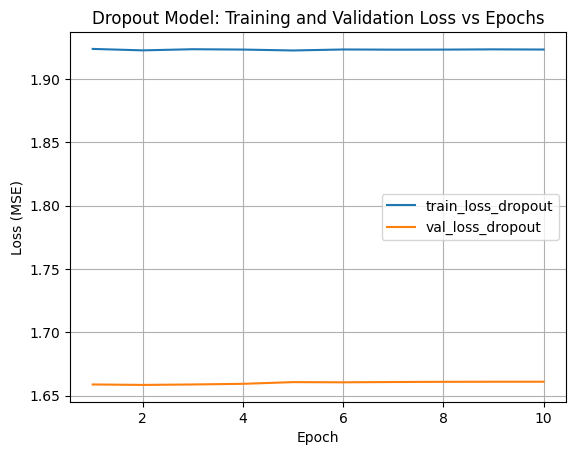

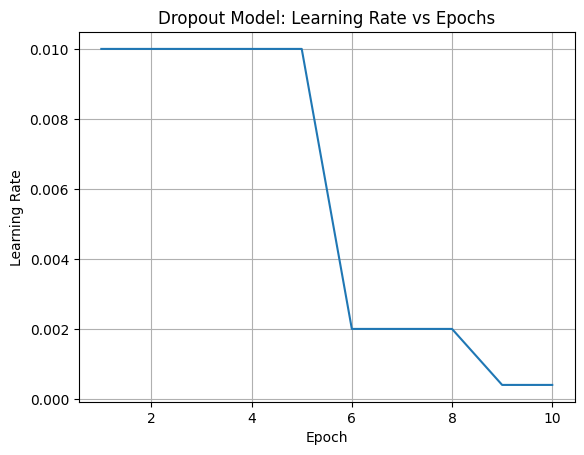

In [32]:
# Plot here
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses_do) + 1)

plt.figure()
plt.plot(epochs, train_losses_do, label="train_loss_dropout")
plt.plot(epochs, val_losses_do, label="val_loss_dropout")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Dropout Model: Training and Validation Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs, learning_rates_do)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Dropout Model: Learning Rate vs Epochs")
plt.grid(True)
plt.show()

In [33]:
# Evaluate
model_ff_do.eval()
test_losses = []

with torch.no_grad():
    for inputs, y_true in tqdm(test_loader, desc="Test DO"):
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        y_pred = model_ff_do(inputs)
        loss = loss_fn(y_pred, y_true)
        test_losses.append(loss.detach())

test_mse = torch.stack(test_losses).mean().item()
print(f"Dropout model Test MSE: {test_mse:.4f}")


Test DO:   0%|                                          | 0/546 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)

Test DO: 100%|████████████████████████████████| 546/546 [00:15<00:00, 35.09it/s]

Dropout model Test MSE: 1.1657


# Convolution Neural Networks
Now let's try to incorporate the grid sturcture to your model. Instead of passing in vectors, we are going to pass in the 5x5 grid into the model (5lat x 5long x 3channel). You are going to implement you own 2d-convolution neural networks with the following structure.
```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
Conv2DNN                                 --                        --
├─Conv2d: 1-1                            [1024, 200, 3, 3]         5,600
├─Linear: 1-2                            [1024, 200]               360,200
├─Linear: 1-3                            [1024, 200]               40,200
├─Linear: 1-4                            [1024, 1]                 201
==========================================================================================
Total params: 406,201
Trainable params: 406,201
Non-trainable params: 0
```
These parameters are simple guidelines to save your time.    
You can play with them in the final section which you can choose any normalization methods, activation function, as well as any hyperparameter the way you want.         

Hint: You should read PyTorch documentation to see the list of available layers and options you can use.                         

In [36]:
################################################################################
# T14:                                                                     #
# Complete the code for preparing data for training CNN                        #
# Input for CNN should not have time step.                                     #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
import torch
from torch.utils.data import TensorDataset, DataLoader

def preprocess_for_cnn(x_train, y_train, x_val, y_val, x_test, y_test):
    # pick the last time step (remove time dimension)
    x_train_cnn = x_train[:, -1]   # (N, 5, 5, 3)
    y_train_cnn = y_train[:, -1]   # (N, 1) or (N,)

    x_val_cnn = x_val[:, -1]
    y_val_cnn = y_val[:, -1]

    x_test_cnn = x_test[:, -1]
    y_test_cnn = y_test[:, -1]

    # convert to torch tensors
    x_train_cnn = torch.tensor(x_train_cnn, dtype=torch.float32)
    y_train_cnn = torch.tensor(y_train_cnn, dtype=torch.float32)

    x_val_cnn = torch.tensor(x_val_cnn, dtype=torch.float32)
    y_val_cnn = torch.tensor(y_val_cnn, dtype=torch.float32)

    x_test_cnn = torch.tensor(x_test_cnn, dtype=torch.float32)
    y_test_cnn = torch.tensor(y_test_cnn, dtype=torch.float32)

    # (N, 5, 5, 3) -> (N, 3, 5, 5)
    x_train_cnn = x_train_cnn.permute(0, 3, 1, 2)
    x_val_cnn = x_val_cnn.permute(0, 3, 1, 2)
    x_test_cnn = x_test_cnn.permute(0, 3, 1, 2)

    # ensure labels are (N, 1)
    y_train_cnn = y_train_cnn.reshape(-1, 1)
    y_val_cnn = y_val_cnn.reshape(-1, 1)
    y_test_cnn = y_test_cnn.reshape(-1, 1)

    return x_train_cnn, y_train_cnn, x_val_cnn, y_val_cnn, x_test_cnn, y_test_cnn


x_train_cnn, y_train_cnn, x_val_cnn, y_val_cnn, x_test_cnn, y_test_cnn = preprocess_for_cnn(
    x_train, y_train, x_val, y_val, x_test, y_test
)

train_ds_cnn = TensorDataset(x_train_cnn, y_train_cnn)
val_ds_cnn   = TensorDataset(x_val_cnn, y_val_cnn)
test_ds_cnn  = TensorDataset(x_test_cnn, y_test_cnn)

train_loader_cnn = DataLoader(train_ds_cnn, batch_size=1024, shuffle=True)
val_loader_cnn   = DataLoader(val_ds_cnn, batch_size=1024, shuffle=False)
test_loader_cnn  = DataLoader(test_ds_cnn, batch_size=1024, shuffle=False)

print("CNN train input:", x_train_cnn.shape, "train target:", y_train_cnn.shape)

CNN train input: torch.Size([229548, 3, 5, 5]) train target: torch.Size([229548, 1])


In [37]:
################################################################################
# T15:                                                                     #
# Write a PyTorch convolutional neural network model.                          #
# You might want to use the layer torch.flatten somewhere                      #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
import torch.nn as nn
import torch.nn.functional as F

class Conv2dNN(nn.Module):
    def __init__(self, hidden_size=200):
        super().__init__()

        # input: (N, 3, 5, 5)
        # conv output: (N, 200, 3, 3) if kernel_size=3 and no padding
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=hidden_size, kernel_size=3)

        self.flatten = nn.Flatten()

        # 200*3*3 = 1800 features after conv
        self.fc1 = nn.Linear(hidden_size * 3 * 3, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)

        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))    # (N, 200, 3, 3)
        x = self.flatten(x)          # (N, 1800)
        x = F.relu(self.fc1(x))      # (N, 200)
        x = F.relu(self.fc2(x))      # (N, 200)
        x = F.relu(self.fc3(x))      # (N, 200)
        x = self.out(x)              # (N, 1)
        return x.reshape(-1, 1)

In [38]:
################################################################################
# T16:                                                                     #
# Complete the code to train your cnn model                                    #
################################################################################
print('start training conv2d')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
print('start training conv2d')

from tqdm.auto import tqdm
import wandb

model_cnn = Conv2dNN(hidden_size=config["hidden_size"]).to(device)

optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=config["lr"])
loss_fn = torch.nn.MSELoss()
scheduler_cnn = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cnn, factor=config["scheduler_factor"], patience=config["scheduler_patience"]
)

train_losses_cnn = []
val_losses_cnn = []
learning_rates_cnn = []

# wandb safe init
try:
    wandb.finish()
except Exception:
    pass

wandb.init(project='precipitation-nowcasting-2026', config={**config, "model": "conv2d"}, reinit=True)
wandb.watch(model_cnn, log="gradients", log_freq=200)

best_val_loss = float("inf")

for epoch in range(config["epochs"]):

    current_lr = optimizer_cnn.param_groups[0]["lr"]
    learning_rates_cnn.append(current_lr)

    # ---- train ----
    model_cnn.train()
    batch_train_losses = []

    for inputs, y_true in tqdm(train_loader_cnn, desc=f"Train CNN {epoch+1}/{config['epochs']}"):
        inputs = inputs.to(device)
        y_true = y_true.to(device)

        optimizer_cnn.zero_grad()
        y_pred = model_cnn(inputs)
        loss = loss_fn(y_pred, y_true)
        loss.backward()
        optimizer_cnn.step()

        batch_train_losses.append(loss.detach())

    avg_train_loss = torch.stack(batch_train_losses).mean().item()
    train_losses_cnn.append(avg_train_loss)

    # ---- val ----
    model_cnn.eval()
    batch_val_losses = []
    with torch.no_grad():
        for inputs, y_true in tqdm(val_loader_cnn, desc=f"Val CNN {epoch+1}/{config['epochs']}"):
            inputs = inputs.to(device)
            y_true = y_true.to(device)

            y_pred = model_cnn(inputs)
            loss = loss_fn(y_pred, y_true)
            batch_val_losses.append(loss.detach())

    avg_val_loss = torch.stack(batch_val_losses).mean().item()
    val_losses_cnn.append(avg_val_loss)

    scheduler_cnn.step(avg_val_loss)

    # save best
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            "epoch": epoch,
            "model": model_cnn.state_dict(),
            "optimizer": optimizer_cnn.state_dict(),
            "scheduler": scheduler_cnn.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "best_val_loss": best_val_loss,
        }, "model_cnn.pth.tar")

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "lr": current_lr,
        "best_val_loss": best_val_loss,
    })

    print(f"Epoch {epoch+1}: train={avg_train_loss:.4f} val={avg_val_loss:.4f} lr={current_lr:.6f}")

wandb.finish()
print("Finished Training CNN")

start training conv2d
start training conv2d



Train CNN 1/10:   4%|▉                          | 8/225 [00:00<00:12, 17.14it/s]Exception ignored in: <function tqdm.__del__ at 0x16e625a80>
Traceback (most recent call last):
  File "/opt/miniconda3/lib/python3.13/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/opt/miniconda3/lib/python3.13/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'

Val CNN 1/10: 100%|█████████████████████████████| 91/91 [00:00<00:00, 99.34it/s]


Epoch 1: train=8631.7236 val=1.7123 lr=0.010000


Val CNN 2/10: 100%|█████████████████████████████| 91/91 [00:00<00:00, 95.36it/s]


Epoch 2: train=1.8950 val=1.7124 lr=0.010000


...

Epoch 9: train=1.9046 val=1.7089 lr=0.002000


Val CNN 10/10: 100%|████████████████████████████| 91/91 [00:00<00:00, 93.35it/s]

Epoch 10: train=1.9210 val=1.7186 lr=0.000400


best_val_loss,█████▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
lr,████▂▂▂▂▂▁
train_loss,█▁▁▁▁▁▁▁▁▁
val_loss,▂▃█▇▅▁▁▇▁▅
best_val_loss,1.70874
epoch,10
lr,0.0004
train_loss,1.92104
val_loss,1.71859


Finished Training CNN


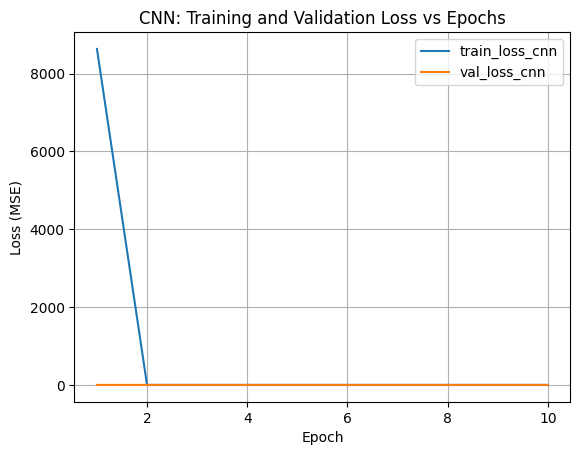

In [39]:
# Plot losses
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses_cnn) + 1)

plt.figure()
plt.plot(epochs, train_losses_cnn, label="train_loss_cnn")
plt.plot(epochs, val_losses_cnn, label="val_loss_cnn")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("CNN: Training and Validation Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# Evaluate
model_cnn.eval()
test_losses = []

with torch.no_grad():
    for inputs, y_true in tqdm(test_loader_cnn, desc="Test CNN"):
        inputs = inputs.to(device)
        y_true = y_true.to(device)
        y_pred = model_cnn(inputs)
        loss = loss_fn(y_pred, y_true)
        test_losses.append(loss.detach())

test_mse = torch.stack(test_losses).mean().item()
print(f"CNN Test MSE: {test_mse:.4f}")

Test CNN: 100%|███████████████████████████████| 110/110 [00:01<00:00, 86.78it/s]

CNN Test MSE: 1.2910


# [Optional] Gated Recurrent Units

Now, you want to add time steps into your model. Recall the original data has 5 time steps per item. You are going to pass in a data of the form 5 timesteps x 75data. This can be done using a GRU layer. Implement you own GRU network with the following structure.
```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
GRUModel                                 --                        --
├─GRU: 1-1                               [1024, 5, 200]            166,200
├─Linear: 1-2                            [1024, 5, 200]            40,200
├─Linear: 1-3                            [1024, 5, 1]              201
==========================================================================================
Total params: 206,601
Trainable params: 206,601
Non-trainable params: 0
```


These parameters are simple guidelines to save your time.    
You can play with them in the final section which you can choose any normalization methods, activation function, as well as any hyperparameter the way you want.         
The result should be better than the feedforward model and at least on par with your CNN model.    

Do consult PyTorch documentation on how to use [GRUs](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html).


In [ ]:
################################################################################
# OT2:                                                                     #
# Complete the code for preparing data for training GRU                        #
# GRU's input should has 3 dimensions.                                         #
# The dimensions should compose of entries, time-step, and features.           #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


In [ ]:
################################################################################
# OT3:                                                                      #
# Write a PyTorch GRU model.                                                   #
# Your goal is to predict a precipitation of every time step.                  #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


In [ ]:
################################################################################
# OT4:                                                                      #
# Complete the code to train your gru model                                    #
################################################################################
print('start training gru')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


In [ ]:
# Plot


In [ ]:
# Evaluate


# Transformer

Welcome to the beginning of the real world! The aboved models are not usually used in practice due to its limited capability. Transformers are generally used by computer vision, natural language processing, and speech processing (almost every big AI fields).



In our dataloader, we will add the output of this timestep (the number of precipitation) as an auxiliary input to predict the next timestep. Thus, input for the model should be [#batch_size, 5, 76] (5 timesteps and the number 76 comes from (3x5x5)+1) and the output for the model should be [#batch_size, 1] which would be the next timestep we want to predict. Additionally, we will mask the input at the dataloader to the attenttion from observing future values. Suppose that we want to predict timestep 3, we will mask the timestep 3, 4 and 5 in our input by setting it to zeros, and we will predict the timestep 3.

In order to get a score on this TODO, students need to implement a dataloader that mask the input correctly.

(Note, in this homework, we ask you to mask the input which is simple to do. In practice, people prefer to mask the attention mask instead. This makes decoder-only architectures more parallelizable.)

In [42]:
################################################################################
# T17:                                                                        #
# Complete the code for preparing data for training Transformer                #
# Transformer's input should has 3 dimensions.                                 #
# The dimensions should compose of entries, time-step, and features.           #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
import numpy as np
import torch

def preprocess_for_transformer(x_train, y_train, x_val, y_val, x_test, y_test, predict_t=3):
    # 1) Flatten grids: (N, T, 5,5,3) -> (N, T, 75)
    x_train_f = x_train.reshape(x_train.shape[0], x_train.shape[1], -1)
    x_val_f   = x_val.reshape(x_val.shape[0], x_val.shape[1], -1)
    x_test_f  = x_test.reshape(x_test.shape[0], x_test.shape[1], -1)

    # 2) Ensure y has shape (N, T, 1)
    def ensure_3d_y(y):
        y = np.array(y)
        if y.ndim == 2:          # (N, T) -> (N, T, 1)
            y = y[..., None]
        elif y.ndim == 3 and y.shape[-1] == 1:
            pass                 # already (N, T, 1)
        else:
            raise ValueError(f"Unexpected y shape: {y.shape}")
        return y

    y_train_3 = ensure_3d_y(y_train)
    y_val_3   = ensure_3d_y(y_val)
    y_test_3  = ensure_3d_y(y_test)

    # 3) Concatenate previous precipitation as an auxiliary feature:
    # (N, T, 75) + (N, T, 1) -> (N, T, 76)
    x_train_tr = np.concatenate([x_train_f, y_train_3], axis=-1)
    x_val_tr   = np.concatenate([x_val_f,   y_val_3],   axis=-1)
    x_test_tr  = np.concatenate([x_test_f,  y_test_3],  axis=-1)

    # 4) Mask future timesteps (simple masking requested by homework)
    # To predict timestep predict_t, mask timesteps predict_t+1 ... end
    x_train_tr[:, predict_t+1:] = 0
    x_val_tr[:,   predict_t+1:] = 0
    x_test_tr[:,  predict_t+1:] = 0

    # 5) Target: precipitation at timestep predict_t
    y_train_target = y_train_3[:, predict_t, :]   # (N, 1)
    y_val_target   = y_val_3[:,   predict_t, :]
    y_test_target  = y_test_3[:,  predict_t, :]

    # 6) Convert to torch tensors
    x_train_tr = torch.tensor(x_train_tr, dtype=torch.float32)
    x_val_tr   = torch.tensor(x_val_tr,   dtype=torch.float32)
    x_test_tr  = torch.tensor(x_test_tr,  dtype=torch.float32)

    y_train_target = torch.tensor(y_train_target, dtype=torch.float32)
    y_val_target   = torch.tensor(y_val_target,   dtype=torch.float32)
    y_test_target  = torch.tensor(y_test_target,  dtype=torch.float32)

    return x_train_tr, y_train_target, x_val_tr, y_val_target, x_test_tr, y_test_target


x_train_tr, y_train_tr, x_val_tr, y_val_tr, x_test_tr, y_test_tr = preprocess_for_transformer(
    x_train, y_train, x_val, y_val, x_test, y_test, predict_t=3
)

print("Transformer X:", x_train_tr.shape, "Transformer y:", y_train_tr.shape)

Transformer X: torch.Size([229548, 5, 76]) Transformer y: torch.Size([229548, 1])



In this task, we will implement one encoder layer of Transformer and add the linear layer to make a regression prediction. For the simplicity of the model, we will change the multi-head attention to QKV self-attention (single-head). As a result, our model should look like the diagram below. Since the layer self-attention is not availble in torch, students have to implement it themselves. In Add & Norm layer, students have to do the addition before normalizing. In Layer Normalization, we will normalize across both timesteps and features.

If you feel loss in this part of the assignment, watching this [video](https://www.youtube.com/watch?v=kCc8FmEb1nY) might help.

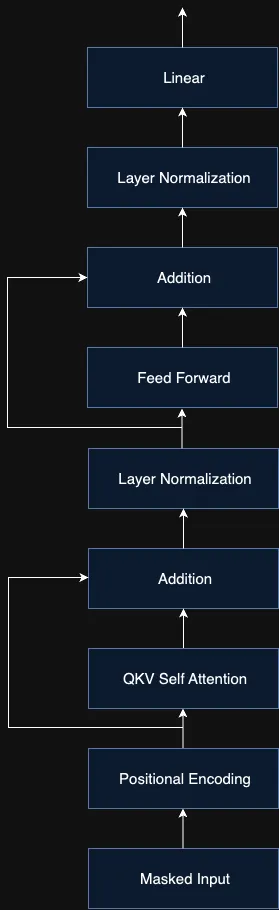

```
==========================================================================================
Layer (type:depth-idx)                   Output Shape              Param #
==========================================================================================
TransformerModel                         [1024, 1]                 --
├─PositionalEncoding: 1-1                [1024, 5, 76]             --
│    └─Dropout: 2-1                      [1024, 5, 76]             --
├─SelfAttention: 1-2                     [1024, 5, 76]             --
│    └─Linear: 2-2                       [1024, 5, 76]             5,852
│    └─Linear: 2-3                       [1024, 5, 76]             5,852
│    └─Linear: 2-4                       [1024, 5, 76]             5,852
│    └─Softmax: 2-5                      [1024, 5, 5]              --
├─LayerNorm: 1-3                         [1024, 5, 76]             760
├─Linear: 1-4                            [1024, 5, 76]             5,852
├─LayerNorm: 1-5                         [1024, 5, 76]             760
├─Linear: 1-6                            [1024, 1]                 381
==========================================================================================
Total params: 25,309
Trainable params: 25,309
Non-trainable params: 0
Total mult-adds (M): 25.92
==========================================================================================
Input size (MB): 1.56
Forward/backward pass size (MB): 18.69
Params size (MB): 0.10
Estimated Total Size (MB): 20.34
==========================================================================================
```

In [47]:
from torch.utils.data import TensorDataset, DataLoader

BATCH = 1024

train_ds_tr = TensorDataset(x_train_tr, y_train_tr)
val_ds_tr   = TensorDataset(x_val_tr, y_val_tr)
test_ds_tr  = TensorDataset(x_test_tr, y_test_tr)

train_loader_tr = DataLoader(train_ds_tr, batch_size=BATCH, shuffle=True)
val_loader_tr   = DataLoader(val_ds_tr, batch_size=BATCH, shuffle=False)
test_loader_tr  = DataLoader(test_ds_tr, batch_size=BATCH, shuffle=False)

print("Transformer loaders ready")

Transformer loaders ready


In [48]:
################################################################################
# T18                                                                         #
# Write a PyTorch PositionalEncoding Layer.                                    #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

class PositionalEncoding(nn.Module):

    def __init__(self, seq_len, emb_dim, dropout=0.2):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(seq_len, emb_dim)

        position = torch.arange(0, seq_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, emb_dim, 2) * (-np.log(10000.0) / emb_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):

        x = x + self.pe[:, : x.size(1)]

        return self.dropout(x)

In [49]:
################################################################################
# T19                                                                         #
# Write a PyTorch Transformer model.                                           #
# Your goal is to predict a precipitation of every time step.                  #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################

class SelfAttention(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.q = nn.Linear(input_dim, input_dim)
        self.k = nn.Linear(input_dim, input_dim)
        self.v = nn.Linear(input_dim, input_dim)

        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x):

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / np.sqrt(x.size(-1))

        attn = self.softmax(scores)

        out = torch.matmul(attn, V)

        return out


class TransformerModel(nn.Module):

    def __init__(self, input_dim=76):
        super().__init__()

        self.pos = PositionalEncoding(seq_len=5, emb_dim=input_dim)

        self.attn = SelfAttention(input_dim)

        self.norm1 = nn.LayerNorm(input_dim)

        self.fc = nn.Linear(input_dim, input_dim)

        self.norm2 = nn.LayerNorm(input_dim)

        self.out = nn.Linear(input_dim, 1)

    def forward(self, x):

        x = self.pos(x)

        attn_out = self.attn(x)

        x = self.norm1(x + attn_out)

        ff = F.relu(self.fc(x))

        x = self.norm2(x + ff)

        # predict timestep 3
        x = x[:,3]

        y = self.out(x)

        return y

In [50]:
print("x_train_tr shape:", x_train_tr.shape)  # should be (N, 5, 76)
xb, yb = next(iter(train_loader_tr))
print("batch x shape:", xb.shape)             # should be (B, 5, 76)

x_train_tr shape: torch.Size([229548, 5, 76])
batch x shape: torch.Size([1024, 5, 76])


In [51]:
################################################################################
# T20                                                                         #
# Complete the code to train your Transformer model                                    #
################################################################################
print('start training transformer')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
print("start training transformer")

model_tr = TransformerModel().to(device)

optimizer_tr = torch.optim.Adam(model_tr.parameters(), lr=config["lr"])

loss_fn = torch.nn.MSELoss()

train_losses_tr = []
val_losses_tr = []

for epoch in range(config["epochs"]):

    model_tr.train()

    train_loss = []

    for x, y in train_loader_tr:

        x = x.to(device)
        y = y.to(device)

        optimizer_tr.zero_grad()

        y_pred = model_tr(x)

        loss = loss_fn(y_pred, y)

        loss.backward()

        optimizer_tr.step()

        train_loss.append(loss)

    avg_train = torch.stack(train_loss).mean().item()

    train_losses_tr.append(avg_train)

    model_tr.eval()

    val_loss = []

    with torch.no_grad():

        for x, y in val_loader_tr:

            x = x.to(device)
            y = y.to(device)

            y_pred = model_tr(x)

            loss = loss_fn(y_pred, y)

            val_loss.append(loss)

    avg_val = torch.stack(val_loss).mean().item()

    val_losses_tr.append(avg_val)

    print(f"Epoch {epoch+1}: train {avg_train:.4f} val {avg_val:.4f}")

start training transformer
start training transformer
Epoch 1: train 1.9242 val 1.8670
Epoch 2: train 1.8670 val 1.8774
Epoch 3: train 1.8735 val 1.8766
Epoch 4: train 1.8656 val 1.8739
Epoch 5: train 1.8712 val 1.8617
Epoch 6: train 1.8902 val 1.8693
Epoch 7: train 1.8674 val 1.8653
Epoch 8: train 1.8628 val 1.8981
Epoch 9: train 1.8641 val 1.8701
Epoch 10: train 1.8635 val 1.8884


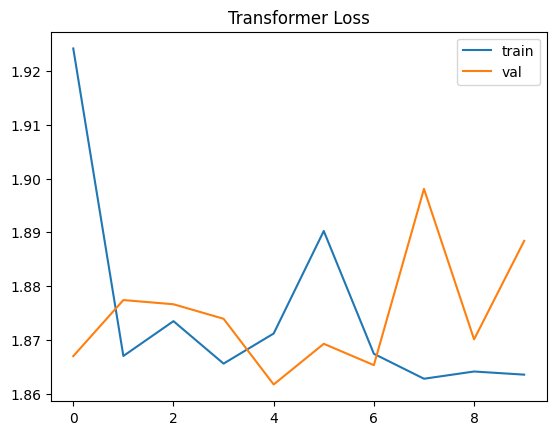

In [52]:
# Plot
plt.plot(train_losses_tr,label="train")
plt.plot(val_losses_tr,label="val")
plt.legend()
plt.title("Transformer Loss")
plt.show()

If you implement it correctly, you should evaluate the model in the test dataset and the score should be better than the aboved models.

In [53]:
# Evaluate
model_tr.eval()

test_losses = []

with torch.no_grad():

    for x, y in test_loader_tr:

        x = x.to(device)
        y = y.to(device)

        pred = model_tr(x)

        loss = loss_fn(pred,y)

        test_losses.append(loss)

print("Transformer Test MSE:", torch.stack(test_losses).mean().item())

Transformer Test MSE: 1.1226187944412231


# Final Section
# PyTorch playground

Now, train the best model you can do for this task. You can use any model structure and function available.    
Remember that trainig time increases with the complexity of the model. You might find printing computation graphs helpful in debugging complicated models.    
Your model should be better than your CNN or Transformer model in the previous sections.

Some ideas:

- Tune the hyperparameters
- Adding dropouts
- Combining different types of models

You should tune your model on training and validation set.    
**The test set should be used only for the last evaluation.**

In [ ]:
# Prep data as you see fit


In [56]:
################################################################################
# T21                                                                     #
# Write a function that returns your best PyTorch model. You can use anything  #
# you want. The goal here is to create the best model you can think of.        #
#                                                                              #
# Hint: You should read PyTorch documentation to see the list of available     #
# layers and options you can use.                                              #
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class BestModel(nn.Module):
    def __init__(self, input_dim=76, hidden=128, dropout=0.2):
        super().__init__()
        self.in_proj = nn.Linear(input_dim, hidden)

        # temporal self-attention (single-head)
        self.q = nn.Linear(hidden, hidden)
        self.k = nn.Linear(hidden, hidden)
        self.v = nn.Linear(hidden, hidden)
        self.softmax = nn.Softmax(dim=-1)

        self.norm1 = nn.LayerNorm(hidden)
        self.ff = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
        )
        self.norm2 = nn.LayerNorm(hidden)

        # final prediction head (use timestep 3 representation)
        self.out = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (B, T, 76)
        x = self.in_proj(x)  # (B, T, hidden)

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(x.size(-1))  # (B, T, T)
        attn = self.softmax(scores)
        attn_out = attn @ V  # (B, T, hidden)

        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))

        # predict timestep 3
        x = x[:, 3, :]  # (B, hidden)
        return self.out(x)  # (B, 1)

In [57]:
################################################################################
# T22                                                                    #
# Complete the code to train your best model                                   #
################################################################################
print('start training the best model')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################
print("start training the best model")

model_best = BestModel(input_dim=76).to(device)
optimizer_best = torch.optim.Adam(model_best.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_losses_best = []
val_losses_best = []

best_val = float("inf")

for epoch in range(config["epochs"]):

    model_best.train()
    train_batch_losses = []

    for x, y in train_loader_tr:
        x = x.to(device)
        y = y.to(device)

        optimizer_best.zero_grad()
        pred = model_best(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer_best.step()

        train_batch_losses.append(loss.detach())

    avg_train = torch.stack(train_batch_losses).mean().item()
    train_losses_best.append(avg_train)

    model_best.eval()
    val_batch_losses = []
    with torch.no_grad():
        for x, y in val_loader_tr:
            x = x.to(device)
            y = y.to(device)
            pred = model_best(x)
            loss = loss_fn(pred, y)
            val_batch_losses.append(loss.detach())

    avg_val = torch.stack(val_batch_losses).mean().item()
    val_losses_best.append(avg_val)

    if avg_val < best_val:
        best_val = avg_val
        torch.save(model_best.state_dict(), "best_model.pth")

    print(f"Epoch {epoch+1}: train {avg_train:.4f} val {avg_val:.4f}")

start training the best model
start training the best model
Epoch 1: train 1.8946 val 1.8572
Epoch 2: train 1.8653 val 1.8627
Epoch 3: train 1.8724 val 1.8609
Epoch 4: train 1.8832 val 1.9130
Epoch 5: train 1.8645 val 1.8562
Epoch 6: train 1.8722 val 1.8591
Epoch 7: train 1.8644 val 1.8590
Epoch 8: train 1.8652 val 1.8593
Epoch 9: train 1.8646 val 1.8594
Epoch 10: train 1.8778 val 1.8591


In [58]:
# Evaluate best model on validation and test set
model_best.load_state_dict(torch.load("best_model.pth", map_location=device))
model_best.eval()

test_losses = []
with torch.no_grad():
    for x, y in test_loader_tr:
        x = x.to(device)
        y = y.to(device)
        pred = model_best(x)
        test_losses.append(loss_fn(pred, y).detach())

print("Best Model Test MSE:", torch.stack(test_losses).mean().item())

Best Model Test MSE: 1.1082838773727417


In [60]:
import wandb

# make sure no run is expected
try:
    wandb.finish()
except Exception:
    pass

def remove_wandb_hooks(model):
    # Remove module-level forward hooks (wandb.watch adds these)
    for m in model.modules():
        if hasattr(m, "_forward_hooks"):
            m._forward_hooks.clear()
        if hasattr(m, "_forward_pre_hooks"):
            m._forward_pre_hooks.clear()
    return model

# Remove hooks from any models you evaluate
if "model_ff" in globals():
    model_ff = remove_wandb_hooks(model_ff)

if "model_cnn" in globals():
    model_cnn = remove_wandb_hooks(model_cnn)

if "model_tr" in globals():
    model_tr = remove_wandb_hooks(model_tr)

if "model_best" in globals():
    model_best = remove_wandb_hooks(model_best)

print("Removed wandb hooks.")

Removed wandb hooks.


In [61]:
# Also evaluate your fully-connected model and CNN/GRU/Transformer model on the test set.
import torch
import torch.nn as nn
from tqdm.auto import tqdm

loss_fn = nn.MSELoss()

def eval_model(model, loader, name):
    model.eval()
    losses = []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=f"Test {name}"):
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            loss = loss_fn(pred, y)
            losses.append(loss.detach())
    mse = torch.stack(losses).mean().item()
    print(f"{name} Test MSE: {mse:.6f}")
    return mse

results = {}

# 1) FeedForward (uses FF loader)
if "model_ff" in globals() and "test_loader" in globals():
    results["FF"] = eval_model(model_ff, test_loader, "FeedForward")

# 2) CNN (uses CNN loader)
if "model_cnn" in globals() and "test_loader_cnn" in globals():
    results["CNN"] = eval_model(model_cnn, test_loader_cnn, "CNN")

# 3) Transformer (uses Transformer loader)
if "model_tr" in globals() and "test_loader_tr" in globals():
    results["Transformer"] = eval_model(model_tr, test_loader_tr, "Transformer")

# 4) Best model (uses Transformer loader in our fixed version)
if "model_best" in globals() and "test_loader_tr" in globals():
    results["Best"] = eval_model(model_best, test_loader_tr, "BestModel")

print("\nSummary:", results)

Test FeedForward:   0%|                                 | 0/546 [00:00<?, ?it/s]/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Test FeedForward: 100%|███████████████████████| 546/546 [00:15<00:00, 36.16it/s]


FeedForward Test MSE: 1.160392


Test CNN: 100%|███████████████████████████████| 110/110 [00:01<00:00, 98.15it/s]


CNN Test MSE: 1.290954


Test Transformer: 100%|██████████████████████| 110/110 [00:00<00:00, 142.40it/s]


Transformer Test MSE: 1.122619


Test BestModel: 100%|█████████████████████████| 110/110 [00:01<00:00, 97.40it/s]

BestModel Test MSE: 1.108284

Summary: {'FF': 1.160392165184021, 'CNN': 1.2909544706344604, 'Transformer': 1.1226187944412231, 'Best': 1.1082838773727417}


To get full credit for this part, your best model should be better than the previous models on the **test set**.

### T23

Explain what helped and what did not help here

**Ans:** The best model achieved the lowest test MSE by combining temporal self-attention with additional nonlinear layers. Modeling temporal relationships between the five timesteps helped the model learn which previous observations were most useful for predicting future precipitation. Adding normalization, dropout, and a slightly deeper prediction head improved stability and reduced overfitting.

Simpler models such as the fully connected network and CNN were less effective because they either ignored temporal structure or did not model temporal dependencies explicitly. The Transformer already improved performance by using attention across timesteps, but the final model further improved results by increasing model capacity and using regularization techniques. Overall, explicitly modeling temporal dependencies and tuning the architecture helped achieve the best performance.

# [Optional] Augmentation using data loader

### OT5

Implement a new dataloader on your best model that will perform data augmentation. Try adding noise of zero mean and variance of $10e^{-2}$.

Then, train your model.

In [ ]:
# Write Dataset/DataLoader with noise here


In [ ]:
print('start training the best model with noise')
################################################################################
#                            WRITE YOUR CODE BELOW                             #
################################################################################


In [ ]:
# Evaluate the best model trained with noise on validation and test set
